<a href="https://colab.research.google.com/github/anushriadapawar/Parking-Lot-Lighting-Forecast/blob/main/Parking_Lot_Lighting_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (3309, 6)


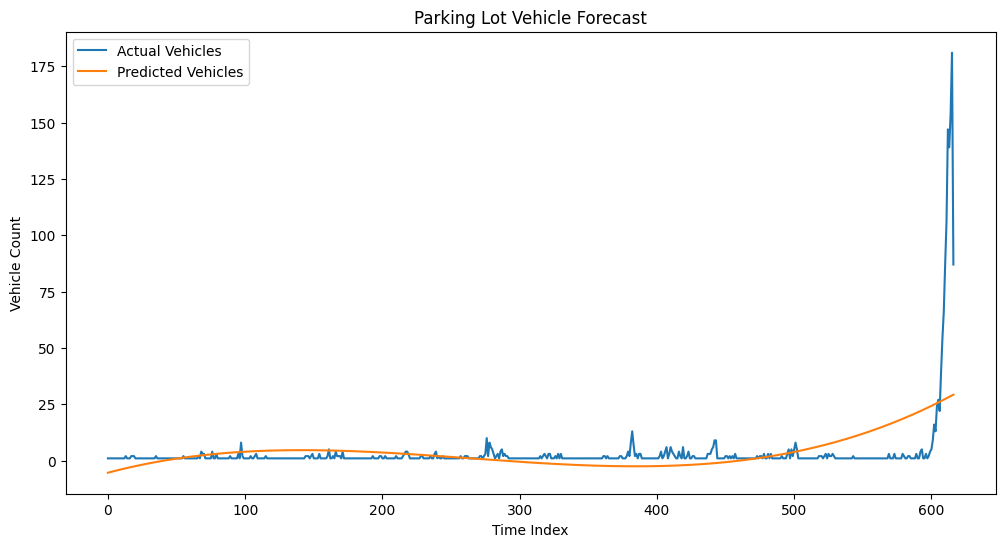


Current Predicted Lighting Level: Medium
⚠ ALERT: Unusual parking activity detected


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

import plotly.express as px

# ------------------------------------------
# Load dataset
# ------------------------------------------

df = pd.read_csv("/content/on-street-parking-bay-sensors.csv")

print("Dataset shape:", df.shape)

# ------------------------------------------
# Data Cleaning
# ------------------------------------------

df['status_timestamp'] = pd.to_datetime(df['status_timestamp'])

df = df.sort_values('status_timestamp')

df['occupied'] = df['status_description'].map({
    'Present':1,
    'Unoccupied':0
})

df = df.dropna(subset=['occupied'])

# ------------------------------------------
# Create Parking Occupancy Time Series
# ------------------------------------------

df = df.set_index('status_timestamp')

# Count number of occupied bays every 15 minutes
vehicle_series = df['occupied'].resample('15min').sum()

vehicle_series = vehicle_series.reset_index()

vehicle_series.rename(columns={'occupied':'vehicle_count'}, inplace=True)

# Remove empty intervals
vehicle_series = vehicle_series[vehicle_series['vehicle_count'] > 0]

vehicle_series = vehicle_series.reset_index(drop=True)

# ------------------------------------------
# Reduce dataset size (important)
# ------------------------------------------

vehicle_series = vehicle_series.head(1500)

# ------------------------------------------
# Create time index
# ------------------------------------------

vehicle_series['time_index'] = np.arange(len(vehicle_series))

# ------------------------------------------
# Scale features
# ------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(vehicle_series[['time_index']])

y = vehicle_series['vehicle_count']

# ------------------------------------------
# Polynomial Regression
# ------------------------------------------

poly = PolynomialFeatures(degree=3)

X_poly = poly.fit_transform(X_scaled)

model = LinearRegression()

model.fit(X_poly, y)

vehicle_series['predicted_vehicles'] = model.predict(X_poly)

# ------------------------------------------
# Lighting Control Logic
# ------------------------------------------

def lighting_level(v):

    if v < 20:
        return "Low"

    elif v < 60:
        return "Medium"

    else:
        return "High"

vehicle_series['lighting_level'] = vehicle_series['predicted_vehicles'].apply(lighting_level)

# ------------------------------------------
# Anomaly Detection
# ------------------------------------------

vehicle_series['error'] = abs(
    vehicle_series['vehicle_count'] -
    vehicle_series['predicted_vehicles']
)

threshold = vehicle_series['error'].mean() + 2*vehicle_series['error'].std()

vehicle_series['anomaly'] = vehicle_series['error'] > threshold

# ------------------------------------------
# Plot Forecast
# ------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(
    vehicle_series['time_index'],
    vehicle_series['vehicle_count'],
    label="Actual Vehicles"
)

plt.plot(
    vehicle_series['time_index'],
    vehicle_series['predicted_vehicles'],
    label="Predicted Vehicles"
)

plt.xlabel("Time Index")
plt.ylabel("Vehicle Count")
plt.title("Parking Lot Vehicle Forecast")

plt.legend()

plt.show()

# ------------------------------------------
# Real-time monitoring chart
# ------------------------------------------

fig = px.bar(
    vehicle_series.head(200),
    x='time_index',
    y='vehicle_count',
    title="Real-Time Parking Occupancy"
)

fig.show()

# ------------------------------------------
# Latest system decision
# ------------------------------------------

latest = vehicle_series.iloc[-1]

print("\nCurrent Predicted Lighting Level:", latest['lighting_level'])

if latest['anomaly']:
    print("⚠ ALERT: Unusual parking activity detected")
else:
    print("System running normally")